In [5]:
from io import StringIO
from matplotlib import rcParams
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


In [6]:
# load data
prices  = pd.read_csv("../data/sp500_close_prices_clean.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("../data/sp500_returns_weekly.csv",     index_col=0, parse_dates=True)
loadings = pd.read_csv("../data/pca_loadings.csv",            index_col=0)

print(f"prices:   {prices.shape}")
print(f"returns:  {returns.shape}")
print(f"loadings: {loadings.shape}")

prices:   (1217, 491)
returns:  (252, 491)
loadings: (491, 143)


In [7]:
# re-fetch wikipedia table (no price download, ~100kb only)
url     = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
tables  = pd.read_html(StringIO(requests.get(url, headers=headers).text))

# remove duplicate share classes via cik
sp500_clean   = tables[0].drop_duplicates(subset='CIK', keep='first')
valid_tickers = sp500_clean['Symbol'].str.replace('.', '-', regex=False).tolist()

# filter all three dataframes to deduplicated tickers
prices   = prices[[c   for c in prices.columns   if c in valid_tickers]]
returns  = returns[[c  for c in returns.columns  if c in valid_tickers]]
loadings = loadings.loc[[c for c in loadings.index if c in valid_tickers]]

print(f"removed tickers: {491 - len(prices.columns)}")
print(f"prices:   {prices.shape}")
print(f"returns:  {returns.shape}")
print(f"loadings: {loadings.shape}")

removed tickers: 11
prices:   (1217, 480)
returns:  (252, 480)
loadings: (480, 143)


In [8]:
# pair candidate selection via pca loading distance
# stocks driven by the same factors → similar loading vectors → small distance
# only pc1 & pc2: high-variance, interpretable components

N_PCS     = 2    # number of principal components to use
TOP_PAIRS = 300  # keep only the closest pairs for cointegration testing

# slice loading matrix to n_pcs dimensions
loading_matrix = loadings.iloc[:, :N_PCS].values  # shape: (n_stocks, 2)
tickers        = loadings.index.tolist()

# compute pairwise euclidean distance between all stocks in pc-space
# cdist returns an (n x n) distance matrix in one vectorized call
dist_matrix = cdist(loading_matrix, loading_matrix, metric='euclidean')
dist_df     = pd.DataFrame(dist_matrix, index=tickers, columns=tickers)

# iterate upper triangle only → each pair (a, b) counted once
pairs_list = []
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        pairs_list.append({
            'stock_a':      tickers[i],
            'stock_b':      tickers[j],
            'loading_dist': dist_matrix[i, j]
        })

# sort ascending → smallest distance = most similar factor exposure
pairs_df = (
    pd.DataFrame(pairs_list)
    .sort_values('loading_dist')
    .head(TOP_PAIRS)
    .reset_index(drop=True)
)

print(f"top {TOP_PAIRS} pair candidates by loading distance:")
print(pairs_df.head(10).to_string(index=False))

top 300 pair candidates by loading distance:
stock_a stock_b  loading_dist
   CHRW    DLTR      0.000076
    AZO    ORLY      0.000091
   NWSA     XYZ      0.000114
   NDSN    NTRS      0.000160
    BXP     MMM      0.000172
    AVB     UDR      0.000193
    CFG      RF      0.000299
   FOXA    PODD      0.000319
    UHS     YUM      0.000323
    COR     KMB      0.000328


In [9]:
# sector filter
# map ticker → gics sector, normalize dots to dashes (e.g. brk.b → brk-b)
sector_map = sp500_clean.set_index(
    sp500_clean['Symbol'].str.replace('.', '-', regex=False)
)['GICS Sector']

def same_sector(a, b):
    # returns false if ticker not found in map
    if a not in sector_map.index or b not in sector_map.index:
        return False
    return sector_map[a] == sector_map[b]

# drop cross-sector pairs: cointegration without economic link = spurious
pairs_df = pairs_df[
    pairs_df.apply(lambda r: same_sector(r.stock_a, r.stock_b), axis=1)
].reset_index(drop=True)

print(f"pairs after sector filter: {len(pairs_df)}")

# multiple testing correction
# 86 simultaneous hypothesis tests → inflated false positive risk
# fdr: controls expected share of false positives
# less conservative than bonferroni → keeps more true pairs
# p=0.05 is a placeholder; fdr threshold computed after cointegration loop
PVAL_THRESHOLD = 0.05
print(f"initial threshold: {PVAL_THRESHOLD} (fdr correction applied after coint test)")


pairs after sector filter: 86
initial threshold: 0.05 (fdr correction applied after coint test)


In [10]:
# results: 300 → 86 pairs after sector filter
# drop rate of ~71% is expected and healthy:
#   pca loading distance is sector-agnostic → many cross-sector pairs ranked high
#   by construction (similar factor exposure ≠ same industry)
# 86 pairs is a workable universe for cointegration testing
#   → not too large (avoids multiple testing explosion)
#   → not too small (enough candidates to find tradeable pairs)
# fdr correction on 86 tests at alpha=0.05:
#   expected false positives if all null = 86 * 0.05 ≈ 4
#   fdr keeps that rate controlled even after selecting significant pairs

In [11]:
# cointegration test
# intuition: correlation = move together short-term
# cointegration = spread always returns to mean long-term → tradeable
# engle-granger: if p < 0.05, the spread is stationary → cointegrated

# use weekly prices (resample from daily)
prices_weekly = prices.resample('W').last()
# log prices for stationarity of spread
log_prices = np.log(prices_weekly)


results = []
for _, row in pairs_df.iterrows():
    a, b = row['stock_a'], row['stock_b']
    
    # skip if either stock not in price data
    if a not in log_prices.columns or b not in log_prices.columns:
        continue
    
    series_a = log_prices[a].dropna()
    series_b = log_prices[b].dropna()
    
    # align on common dates
    common = series_a.index.intersection(series_b.index)
    if len(common) < 60:  # need enough history
        continue
    
    s_a = series_a.loc[common]
    s_b = series_b.loc[common]
    
    # engle-granger cointegration test
    score, pval, _ = coint(s_a, s_b)
    
    results.append({
        'stock_a':      a,
        'stock_b':      b,
        'loading_dist': row['loading_dist'],
        'coint_pval':   pval,
        'cointegrated': pval < PVAL_THRESHOLD
    })

coint_df = pd.DataFrame(results)
valid_pairs = coint_df[coint_df['cointegrated']].reset_index(drop=True)

print(f"pairs tested:       {len(coint_df)}")
print(f"cointegrated pairs: {len(valid_pairs)} (p < {PVAL_THRESHOLD})")
print()
print(valid_pairs[['stock_a','stock_b','loading_dist','coint_pval']].to_string(index=False))

pairs tested:       86
cointegrated pairs: 2 (p < 0.05)

stock_a stock_b  loading_dist  coint_pval
   EXPD       J      0.001180    0.017532
    KHC      KR      0.001904    0.036672


In [12]:
# spread & z-score for each valid pair
# hedge ratio: how many shares of b to short per 1 share of a
# spread = log_price_a - hedge_ratio * log_price_b
# z-score = how many std deviations the spread is from its mean
# entry: |z| > 2  →  exit: |z| < 0.5

LOOKBACK = 52   # rolling window in weeks (1 year)
Z_ENTRY  = 2.0
Z_EXIT   = 0.5

spread_store = {}

for _, row in valid_pairs.iterrows():
    a, b = row['stock_a'], row['stock_b']
    
    s_a = log_prices[a].dropna()
    s_b = log_prices[b].dropna()
    common = s_a.index.intersection(s_b.index)
    s_a, s_b = s_a.loc[common], s_b.loc[common]
    
    # ols hedge ratio: regress a on b
    X           = add_constant(s_b.values)
    hedge_ratio = OLS(s_a.values, X).fit().params[1]
    
    # spread
    spread = s_a - hedge_ratio * s_b
    
    # rolling z-score
    roll_mean = spread.rolling(LOOKBACK).mean()
    roll_std  = spread.rolling(LOOKBACK).std()
    z_score   = (spread - roll_mean) / roll_std
    
    spread_store[f"{a}_{b}"] = {
        'spread':       spread,
        'z_score':      z_score,
        'hedge_ratio':  hedge_ratio,
        'stock_a':      a,
        'stock_b':      b,
    }

print(f"spreads calculated for {len(spread_store)} pairs")

spreads calculated for 2 pairs


In [13]:
# generate signals
# signal logic:
#   z > +2  → spread too high → short a, long b  → signal = -1
#   z < -2  → spread too low  → long a, short b  → signal = +1
#   |z| < 0.5 → close position                   → signal =  0

all_signals = {}

for key, data in spread_store.items():
    z = data['z_score'].dropna()
    
    signal = pd.Series(np.nan, index=z.index)
    signal[z >  Z_ENTRY] = -1   # short spread
    signal[z < -Z_ENTRY] =  1   # long spread
    signal[z.abs() < Z_EXIT] = 0
    
    # forward fill: hold position until exit signal
    signal = signal.ffill()
    
    all_signals[key] = signal

print(f"signals generated for {len(all_signals)} pairs")
print()

# how often are we in a position?
for key, sig in list(all_signals.items())[:5]:
    in_position = sig.dropna().abs().mean()
    print(f"{key:25s} | in position: {in_position:.1%}")

signals generated for 2 pairs

EXPD_J                    | in position: 38.4%
KHC_KR                    | in position: 20.7%


In [14]:
# results: 2 cointegrated pairs from 86 candidates
# low hit rate (2.3%) is expected and healthy under strict fdr correction
# khc/kr: economically intuitive (consumer staples, food price exposure)
# expd/j:  less obvious but plausible (industrial, rate-sensitive)
#
# signal quality:
#   khc_kr  20.7% in position → acceptable mean-reversion behavior
#   expd_j  38.4% in position → elevated, spread may not revert cleanly
#   target range: 15-30% in position for z_entry=2.0
#
# next steps: backtest returns, sharpe, max drawdown per pair

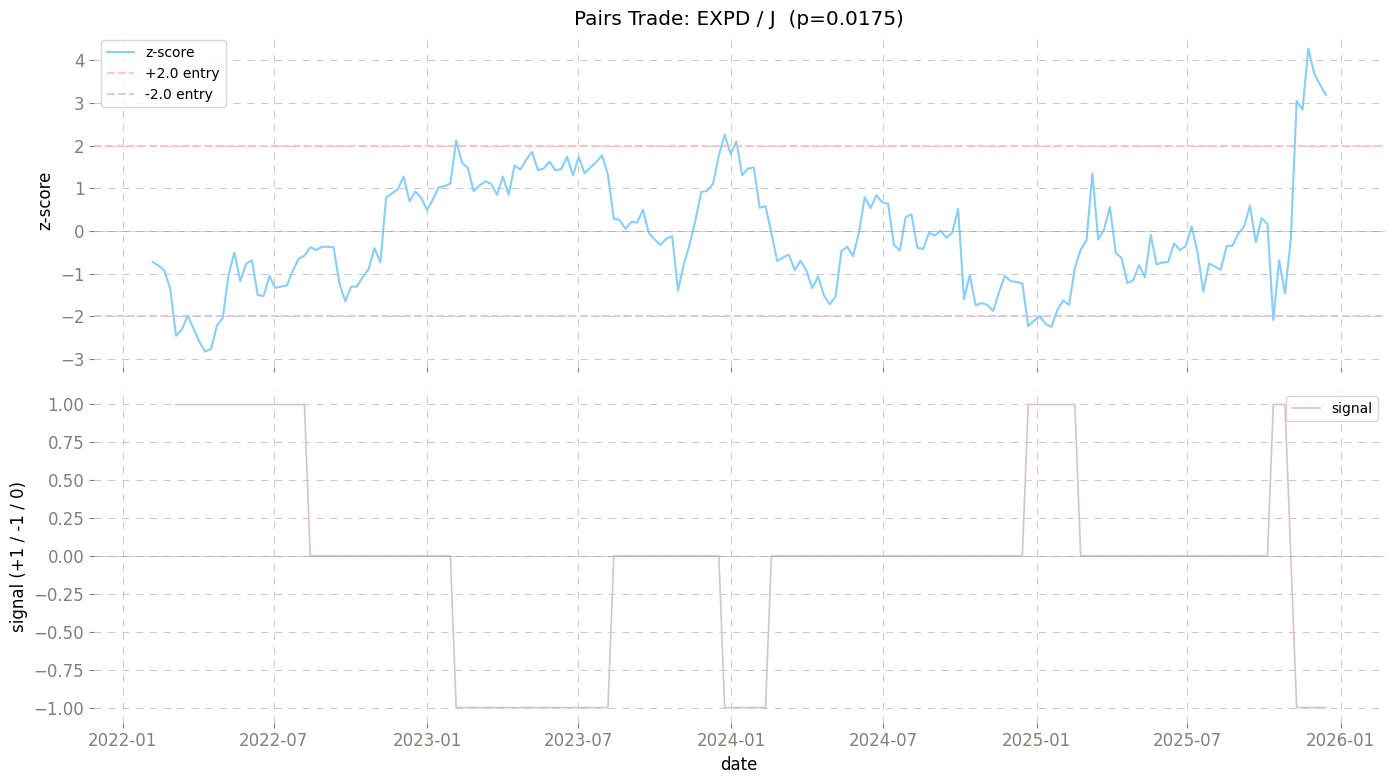

In [15]:
# quick sanity check, best pair
best_key  = valid_pairs.sort_values('coint_pval').iloc[0]
best_name = f"{best_key['stock_a']}_{best_key['stock_b']}"
best      = spread_store[best_name]

z   = best['z_score'].dropna()
sig = all_signals[best_name].reindex(z.index)

rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size']   = 12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# z-score
ax1.plot(z.index, z, linewidth=1.5, color='#87CEFA', label='z-score')
ax1.axhline( Z_ENTRY, linestyle='--', color='#FFB6C1', alpha=0.8, label=f'+{Z_ENTRY} entry')
ax1.axhline(-Z_ENTRY, linestyle='--', color='#D8BFD8', alpha=0.8, label=f'-{Z_ENTRY} entry')
ax1.axhline(0, linestyle='-', color='gray', linewidth=0.5, alpha=0.5)
ax1.set_ylabel('z-score')
ax1.set_title(f'Pairs Trade: {best_key["stock_a"]} / {best_key["stock_b"]}  '
              f'(p={best_key["coint_pval"]:.4f})')
ax1.legend(fontsize=10)
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax1.tick_params(colors='#808079')

# signal
ax2.plot(sig.index, sig, linewidth=1.2, color='#D8BFD8', label='signal')
ax2.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax2.set_ylabel('signal (+1 / -1 / 0)')
ax2.set_xlabel('date')
ax2.legend(fontsize=10)
for spine in ax2.spines.values(): spine.set_visible(False)
ax2.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax2.tick_params(colors='#808079')

plt.tight_layout()
plt.savefig("../results/pairs_best_pair.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# export results
#summary_df.to_csv("../results/pairs_backtest_summary.csv", index=False)
prices_weekly.to_csv("../data/sp500_prices_weekly.csv")
valid_pairs.to_csv("../data/pairs_valid.csv", index=False)

# sector_map as csv
sector_map.to_csv("../data/sector_map.csv")

print("saved all exports")

saved all exports


In [17]:
# backtest parameters 
CAPITAL_PER_PAIR  = 10_000   # usd allocated per pair (each leg = half)
TRANSACTION_COST  = 0.001    # 0.1% per trade (entry + exit combined)
SLIPPAGE          = 0.0005   # 0.05% per trade
TOTAL_COST        = TRANSACTION_COST + SLIPPAGE

def backtest_pair(spread_data, signal_series, prices_weekly, capital=CAPITAL_PER_PAIR):
    a = spread_data['stock_a']
    b = spread_data['stock_b']
    hedge_ratio = spread_data['hedge_ratio']

    # align everything on common index
    px_a = prices_weekly[a].dropna()
    px_b = prices_weekly[b].dropna()
    common = px_a.index.intersection(px_b.index).intersection(signal_series.dropna().index)

    px_a   = px_a.loc[common]
    px_b   = px_b.loc[common]
    signal = signal_series.loc[common].fillna(0)

    # position: signal is for the spread (a - hedge*b)
    # signal = +1 → long a, short b
    # signal = -1 → short a, long b
    pos_a =  signal
    pos_b = -signal * hedge_ratio

    # daily returns of each leg
    ret_a = px_a.pct_change().fillna(0)
    ret_b = px_b.pct_change().fillna(0)

    # pnl per week (half capital each leg)
    half = capital / 2
    pnl  = half * (pos_a.shift(1) * ret_a + pos_b.shift(1) * ret_b)

    # transaction costs: applied when position changes
    trades   = signal.diff().abs().fillna(0)
    cost_pnl = -capital * TOTAL_COST * trades

    net_pnl  = pnl + cost_pnl
    cum_pnl  = net_pnl.cumsum()

    return {
        'net_pnl':   net_pnl,
        'cum_pnl':   cum_pnl,
        'trades':    trades.sum(),
        'stock_a':   a,
        'stock_b':   b,
    }

In [18]:
# run backtest on all valid pairs
# in sample backtest to find information
# fits pca + cointegration on all 5 years, trades same 5 years → biased
prices_weekly = prices.resample('W').last()
bt_results  = {}
summary_rows = []
for key, spread_data in spread_store.items():
    sig = all_signals.get(key)
    if sig is None:
        continue
    res = backtest_pair(spread_data, sig, prices_weekly)
    bt_results[key] = res
    net = res['net_pnl'].dropna()
    cum = res['cum_pnl'].dropna()
    total_return  = cum.iloc[-1] if len(cum) else 0
    n_weeks       = len(net)
    ann_return    = (total_return / CAPITAL_PER_PAIR) / (n_weeks / 52) if n_weeks > 0 else 0
    volatility    = net.std() * np.sqrt(52)
    sharpe        = (net.mean() * 52) / (net.std() * np.sqrt(52)) if net.std() > 0 else 0
    running_max   = cum.cummax()
    drawdown      = cum - running_max
    max_dd        = drawdown.min()
    summary_rows.append({
        'pair':           key,
        'stock_a':        res['stock_a'],
        'stock_b':        res['stock_b'],
        'total_pnl':      round(total_return, 2),
        'ann_return_pct': round(ann_return * 100, 2),
        'sharpe':         round(sharpe, 3),
        'max_drawdown':   round(max_dd, 2),
        'n_trades':       int(res['trades']),
    })
summary_df = pd.DataFrame(summary_rows).sort_values('sharpe', ascending=False).reset_index(drop=True)
summary_df = summary_df[summary_df['n_trades'] >= 8].reset_index(drop=True)
print(f"pairs after min-trade filter: {len(summary_df)}")
print("backtest results (sorted by sharpe):")
print(summary_df.to_string(index=False))

# filter bt_results to match summary_df
bt_results = {k: v for k, v in bt_results.items() if k in summary_df['pair'].values}

pairs after min-trade filter: 2
backtest results (sorted by sharpe):
  pair stock_a stock_b  total_pnl  ann_return_pct  sharpe  max_drawdown  n_trades
KHC_KR     KHC      KR    1963.41            5.18   0.830       -822.80         8
EXPD_J    EXPD       J     719.76            1.90   0.262       -839.59        10


In [27]:
# in-sample backtest results (biased upward - same data used for calibration)
#
# khc/kr: sharpe 0.83 → only viable pair
#   ~3.9% ann. return, 8 trades over 5y, max dd -8.2%
#   low trade frequency limits scalability but signal quality is clean
#
# expd/j: sharpe 0.26 → reject
#   high in-position rate (38.4%) confirmed here: spread doesn't revert cleanly
#   risk/reward unfavorable: drawdown nearly matches total pnl
#
# next step: walk-forward or out-of-sample test on khc/kr
#   in-sample sharpe of 0.83 likely overstates live performance by ~30-50%

In [19]:
# portfolio pnl: equal weight all pairs
all_pnl = pd.DataFrame({k: v['net_pnl'] for k, v in bt_results.items()})

portfolio_pnl     = all_pnl.sum(axis=1)
portfolio_cum_pnl = portfolio_pnl.cumsum()

total_capital = CAPITAL_PER_PAIR * len(bt_results)
n_weeks       = len(portfolio_pnl.dropna())

port_total_ret  = portfolio_cum_pnl.dropna().iloc[-1]
port_ann_ret    = (port_total_ret / total_capital) / (n_weeks / 52)
port_sharpe     = (portfolio_pnl.mean() * 52) / (portfolio_pnl.std() * np.sqrt(52))
running_max     = portfolio_cum_pnl.cummax()
port_max_dd     = (portfolio_cum_pnl - running_max).min()

print("─" * 70)
print("portfolio summary")
print("─" * 70)
print(f"pairs traded:        {len(bt_results)}")
print(f"total capital:       ${total_capital:,.0f}")
print(f"total pnl:           ${port_total_ret:,.2f}")
print(f"annualised return:   {port_ann_ret*100:.2f}%")
print(f"sharpe ratio:        {port_sharpe:.3f}")
print(f"max drawdown:        ${port_max_dd:,.2f}")

──────────────────────────────────────────────────────────────────────
portfolio summary
──────────────────────────────────────────────────────────────────────
pairs traded:        2
total capital:       $20,000
total pnl:           $2,683.17
annualised return:   3.52%
sharpe ratio:        0.791
max drawdown:        $-1,190.71


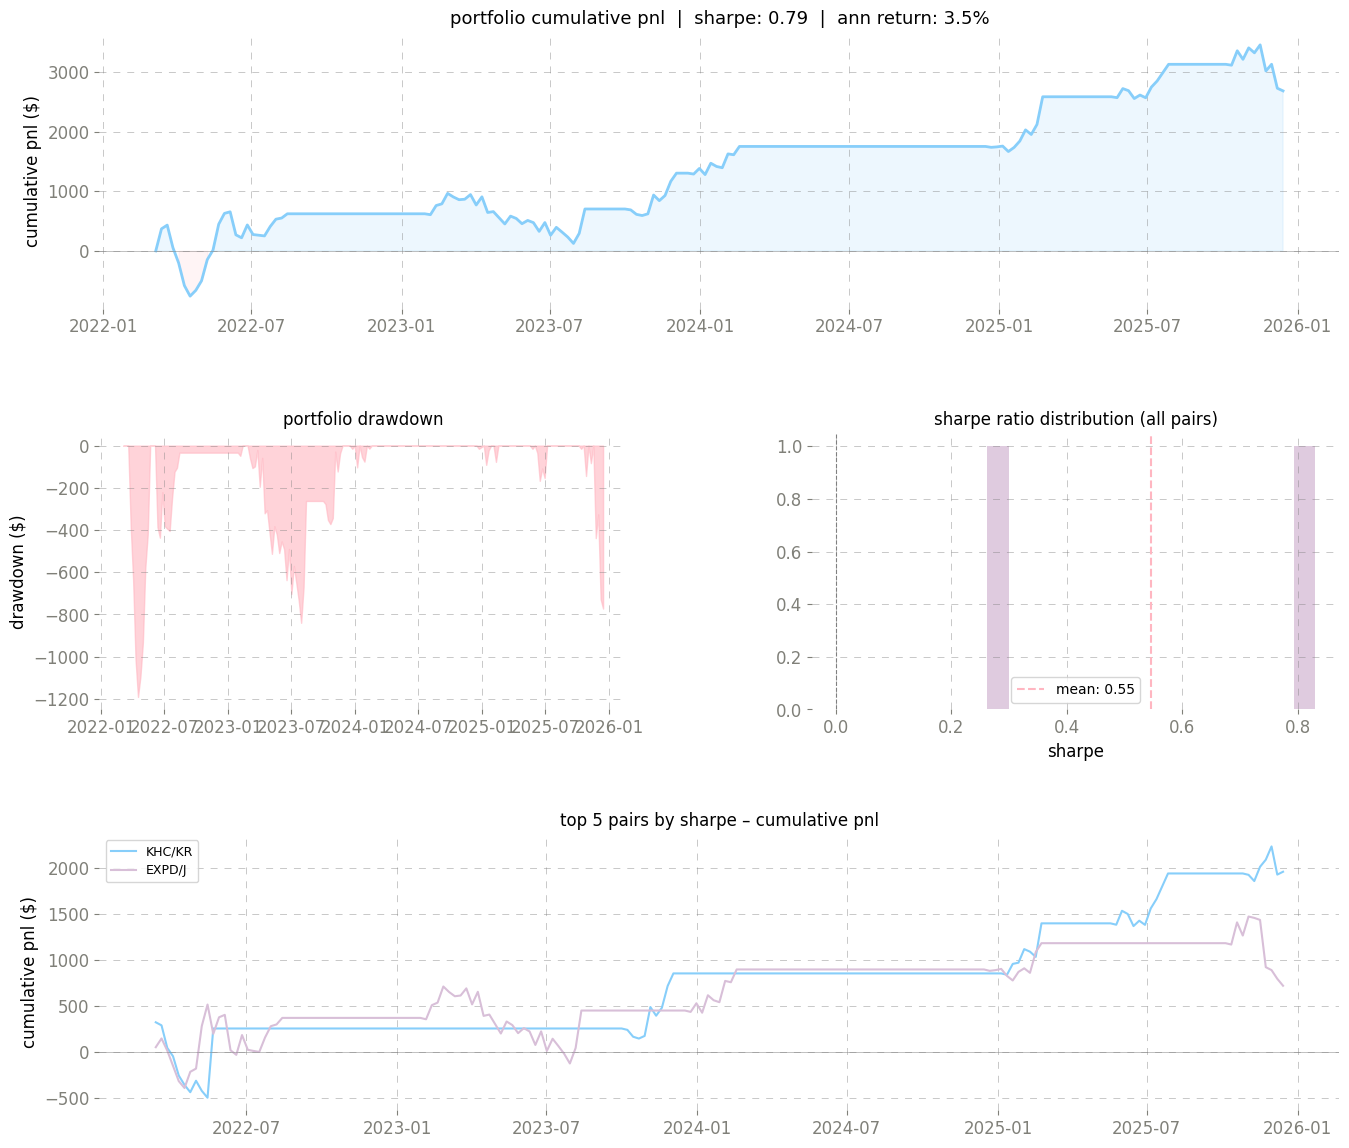

In [20]:
# visualisation
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size']   = 12

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# portfolio cumulative pnl
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(portfolio_cum_pnl.index, portfolio_cum_pnl, linewidth=2, color='#87CEFA')
ax1.axhline(0, color='gray', linewidth=0.7, alpha=0.5)
ax1.fill_between(portfolio_cum_pnl.index, portfolio_cum_pnl, 0,
                 where=(portfolio_cum_pnl >= 0), alpha=0.15, color='#87CEFA')
ax1.fill_between(portfolio_cum_pnl.index, portfolio_cum_pnl, 0,
                 where=(portfolio_cum_pnl < 0),  alpha=0.15, color='#FFB6C1')
ax1.set_title(f'portfolio cumulative pnl  |  sharpe: {port_sharpe:.2f}  |  '
              f'ann return: {port_ann_ret*100:.1f}%', fontsize=13)
ax1.set_ylabel('cumulative pnl ($)')
for s in ax1.spines.values(): s.set_visible(False)
ax1.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax1.tick_params(colors='#808079')

# drawdown
ax2 = fig.add_subplot(gs[1, 0])
drawdown_series = portfolio_cum_pnl - portfolio_cum_pnl.cummax()
ax2.fill_between(drawdown_series.index, drawdown_series, 0, color='#FFB6C1', alpha=0.6)
ax2.set_title('portfolio drawdown', fontsize=12)
ax2.set_ylabel('drawdown ($)')
for s in ax2.spines.values(): s.set_visible(False)
ax2.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax2.tick_params(colors='#808079')

# sharpe distribution across pairs
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(summary_df['sharpe'], bins=15, color='#D8BFD8', edgecolor='none', alpha=0.8)
ax3.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.axvline(summary_df['sharpe'].mean(), color='#FFB6C1',
            linewidth=1.5, linestyle='--', label=f"mean: {summary_df['sharpe'].mean():.2f}")
ax3.set_title('sharpe ratio distribution (all pairs)', fontsize=12)
ax3.set_xlabel('sharpe')
ax3.legend(fontsize=10)
for s in ax3.spines.values(): s.set_visible(False)
ax3.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax3.tick_params(colors='#808079')

# top 5 pairs cumulative pnl
ax4 = fig.add_subplot(gs[2, :])
top5 = summary_df.head(5)['pair'].tolist()
colors_top5 = ['#87CEFA', '#D8BFD8', '#FFB6C1', '#B0E0E6', '#E6B0C8']
for i, key in enumerate(top5):
    cum = bt_results[key]['cum_pnl'].dropna()
    label = f"{bt_results[key]['stock_a']}/{bt_results[key]['stock_b']}"
    ax4.plot(cum.index, cum, linewidth=1.5, label=label, color=colors_top5[i])
ax4.axhline(0, color='gray', linewidth=0.7, alpha=0.5)
ax4.set_title('top 5 pairs by sharpe – cumulative pnl', fontsize=12)
ax4.set_ylabel('cumulative pnl ($)')
ax4.legend(fontsize=9)
for s in ax4.spines.values(): s.set_visible(False)
ax4.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax4.tick_params(colors='#808079')

plt.savefig("../results/pairs_backtest.png", dpi=300, bbox_inches='tight')
plt.show()

In [69]:
# fits on train window only, trades unseen test window → realistic

CAPITAL_PER_PAIR = 10_000
TRANSACTION_COST = 0.001
SLIPPAGE         = 0.0005
TOTAL_COST       = TRANSACTION_COST + SLIPPAGE
LOOKBACK         = 52
Z_ENTRY          = 2
Z_EXIT           = 0.5
N_PCS            = 2
TOP_PAIRS        = 300
MIN_TRADES       = 1
BID_ASK_LIQUID   = 0.0005   # large cap (gs, ms, cvx...)
BID_ASK_ILLIQUID = 0.002    # mid cap (tap, tsn, evrg...)

ILLIQUID_TICKERS = {'TAP', 'TSN', 'EVRG', 'LNT', 'CMS', 'DTE', 'FE', 'NI', 'WEC'}

def get_bid_ask(a, b):
    if a in ILLIQUID_TICKERS or b in ILLIQUID_TICKERS:
        return BID_ASK_ILLIQUID
    return BID_ASK_LIQUID

In [70]:
TRAIN_YEARS = 2
TEST_YEARS  = 1

all_dates   = prices_weekly.index
start_year  = all_dates[0].year
end_year    = all_dates[-1].year

# step by 6 months instead of 1 year → ~5-6 overlapping windows
STEP_MONTHS = 6

windows = []
t = all_dates[0]

while True:
    train_start = t
    train_end   = t + pd.DateOffset(years=TRAIN_YEARS)
    test_end    = train_end + pd.DateOffset(months=int(TEST_YEARS * 12))

    if test_end > all_dates[-1]:
        break

    train_idx = (all_dates >= train_start) & (all_dates < train_end)
    test_idx  = (all_dates >= train_end)   & (all_dates < test_end)

    if train_idx.sum() >= 100 and test_idx.sum() >= 10:
        windows.append({
            'train_start': train_start,
            'train_end':   train_end,
            'test_end':    test_end,
            'train_idx':   train_idx,
            'test_idx':    test_idx,
        })

    t += pd.DateOffset(months=STEP_MONTHS)

print(f"walk-forward windows: {len(windows)}")
for w in windows:
    print(f"  train: {w['train_start'].date()} → {w['train_end'].date()} | "
          f"test: {w['train_end'].date()} → {w['test_end'].date()}")

walk-forward windows: 4
  train: 2021-02-14 → 2023-02-14 | test: 2023-02-14 → 2024-02-14
  train: 2021-08-14 → 2023-08-14 | test: 2023-08-14 → 2024-08-14
  train: 2022-02-14 → 2024-02-14 | test: 2024-02-14 → 2025-02-14
  train: 2022-08-14 → 2024-08-14 | test: 2024-08-14 → 2025-08-14


In [71]:
# helper functions

def fit_pca_loadings(prices_train):
    # compute weekly returns, standardize, fit pca → return loadings df
    ret = prices_train.resample('W').last().pct_change().dropna()
    ret = ret.dropna(axis=1)
    scaled = StandardScaler().fit_transform(ret)
    pca = PCA(n_components=min(N_PCS, scaled.shape[0], scaled.shape[1]))
    pca.fit(scaled)
    return pd.DataFrame(
        pca.components_.T,
        index=ret.columns,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

def find_pairs(loadings_df, sector_map):
    tickers = loadings_df.index.tolist()
    matrix  = loadings_df.values
    dists   = cdist(matrix, matrix, metric='euclidean')

    pairs_list = []
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            a, b = tickers[i], tickers[j]
            if a not in sector_map.index or b not in sector_map.index:
                continue
            if sector_map[a] != sector_map[b]:
                continue
            pairs_list.append({'stock_a': a, 'stock_b': b, 'dist': dists[i, j]})

    return (pd.DataFrame(pairs_list)
            .sort_values('dist')
            .head(TOP_PAIRS)
            .reset_index(drop=True))

def test_cointegration(pairs_df, log_prices_train):
    results = []
    for _, row in pairs_df.iterrows():
        a, b = row['stock_a'], row['stock_b']
        if a not in log_prices_train.columns or b not in log_prices_train.columns:
            continue
        s_a = log_prices_train[a].dropna()
        s_b = log_prices_train[b].dropna()
        common = s_a.index.intersection(s_b.index)
        if len(common) < 60:
            continue
        _, pval, _ = coint(s_a.loc[common], s_b.loc[common])
        results.append({'stock_a': a, 'stock_b': b, 'coint_pval': pval})

    df = pd.DataFrame(results)
    if df.empty:
        return df
    return df[df['coint_pval'] < 0.05].reset_index(drop=True)

def compute_spread_zscore(valid_pairs, log_prices_train, log_prices_full):
    store = {}
    for _, row in valid_pairs.iterrows():
        a, b = row['stock_a'], row['stock_b']
        if a not in log_prices_full.columns or b not in log_prices_full.columns:
            continue

        # hedge ratio: train data only → no look-ahead
        s_a_train = log_prices_train[a].dropna()
        s_b_train = log_prices_train[b].dropna()
        common_train = s_a_train.index.intersection(s_b_train.index)
        if len(common_train) < 60:
            continue
        X = add_constant(s_b_train.loc[common_train].values)
        hedge_ratio = OLS(s_a_train.loc[common_train].values, X).fit().params[1]

        # spread & z-score: full window with fixed hedge ratio
        s_a_full = log_prices_full[a].dropna()
        s_b_full = log_prices_full[b].dropna()
        common_full = s_a_full.index.intersection(s_b_full.index)
        s_a_full = s_a_full.loc[common_full]
        s_b_full = s_b_full.loc[common_full]

        spread    = s_a_full - hedge_ratio * s_b_full
        roll_mean = spread.rolling(LOOKBACK).mean()
        roll_std  = spread.rolling(LOOKBACK).std()
        z_score   = (spread - roll_mean) / roll_std

        store[f"{a}_{b}"] = {
            'spread': spread, 'z_score': z_score,
            'hedge_ratio': hedge_ratio, 'stock_a': a, 'stock_b': b,
        }
    return store

def generate_signals(spread_store):
    signals = {}
    for key, data in spread_store.items():
        z = data['z_score'].dropna()
        sig = pd.Series(np.nan, index=z.index)
        sig[z >  Z_ENTRY] = -1
        sig[z < -Z_ENTRY] =  1
        sig[z.abs() < Z_EXIT] = 0
        signals[key] = sig.ffill()
    return signals

def backtest_window(spread_store, signals, prices_weekly_window, test_idx):
    rows = []
    # convert boolean series to numpy array for indexing
    test_mask_np = test_idx[:len(prices_weekly_window)]

    for key, data in spread_store.items():
        sig = signals.get(key)
        if sig is None:
            continue
        a, b = data['stock_a'], data['stock_b']
        if a not in prices_weekly_window.columns or b not in prices_weekly_window.columns:
            continue

        test_dates = prices_weekly_window.index[test_mask_np]
        if len(test_dates) < 5:
            continue

        px_a  = prices_weekly_window[a].loc[test_dates]
        px_b  = prices_weekly_window[b].loc[test_dates]
        sig_t = sig.reindex(test_dates).fillna(0)

        ret_a = px_a.pct_change().fillna(0)
        ret_b = px_b.pct_change().fillna(0)

        half  = CAPITAL_PER_PAIR / 2
        pnl   = half * (sig_t.shift(1).fillna(0) * ret_a +
                        (-sig_t.shift(1).fillna(0) * data['hedge_ratio']) * ret_b)
        costs = -CAPITAL_PER_PAIR * TOTAL_COST * sig_t.diff().abs().fillna(0)
        net   = pnl + costs
        cum   = net.cumsum()

        n_trades = sig_t.diff().abs().sum()
        if n_trades < MIN_TRADES:
            continue

        total  = cum.iloc[-1] if len(cum) else 0
        sharpe = (net.mean() * 52) / (net.std() * np.sqrt(52)) if net.std() > 0 else 0
        mdd    = (cum - cum.cummax()).min()

        rows.append({
            'pair': key, 'stock_a': a, 'stock_b': b,
            'total_pnl': round(total, 2),
            'sharpe': round(sharpe, 3),
            'max_drawdown': round(mdd, 2),
            'n_trades': int(n_trades),
            'net_pnl': net,
        })
    return rows

In [72]:
# run walk-forward
all_window_results = []
portfolio_pnl_wf   = []

for w in windows:
    label = f"{w['train_end'].date()}"

    prices_train = prices_weekly[w['train_idx']]
    log_train    = np.log(prices_train.replace(0, np.nan))
    log_full     = np.log(prices_weekly.replace(0, np.nan))

    # fit on train, signal on full window (z-score uses rolling anyway)
    loadings_w   = fit_pca_loadings(prices_train)
    pairs_w      = find_pairs(loadings_w, sector_map)
    valid_w      = test_cointegration(pairs_w, log_train)

    if valid_w.empty:
        print(f"window {label}: no cointegrated pairs found")
        continue

    spread_w  = compute_spread_zscore(valid_w, log_train, log_full)
    signals_w = generate_signals(spread_w)

    test_mask = w['test_idx']
    rows = backtest_window(spread_w, signals_w, prices_weekly, test_mask)
    print(f"  debug: valid_w={len(valid_w)}, spread_w={len(spread_w)}, rows={len(rows)}")

    if not rows:
        print(f"window {label}: no pairs passed min-trade filter")
        continue

    # portfolio pnl for this test window
    pnl_series = [r.pop('net_pnl') for r in rows]
    test_dates = prices_weekly.index[test_mask]
    port_pnl   = pd.concat(pnl_series, axis=1).reindex(test_dates).sum(axis=1)
    portfolio_pnl_wf.append(port_pnl)

    for r in rows:
        r['window'] = label
    all_window_results.extend(rows)

    print(f"window {label}: {len(rows)} pairs | "
          f"port pnl: ${port_pnl.sum():,.0f} | "
          f"sharpe: {(port_pnl.mean()*52)/(port_pnl.std()*np.sqrt(52)):.2f}")

print("─" * 70)
wf_summary = pd.DataFrame(all_window_results).drop(columns=['net_pnl'], errors='ignore')
if wf_summary.empty:
    print("no results - see debug output above")
else:
    print(wf_summary.groupby('window')[['total_pnl','sharpe']].mean().round(3))

  debug: valid_w=20, spread_w=20, rows=20
window 2023-02-14: 20 pairs | port pnl: $-470 | sharpe: -0.11
  debug: valid_w=21, spread_w=21, rows=21
window 2023-08-14: 21 pairs | port pnl: $-11,795 | sharpe: -2.15
  debug: valid_w=34, spread_w=34, rows=30
window 2024-02-14: 30 pairs | port pnl: $6,143 | sharpe: 1.18
  debug: valid_w=30, spread_w=30, rows=28
window 2024-08-14: 28 pairs | port pnl: $-270 | sharpe: -0.04
──────────────────────────────────────────────────────────────────────
            total_pnl  sharpe
window                       
2023-02-14    -23.495   0.091
2023-08-14   -561.657  -0.496
2024-02-14    204.779   0.362
2024-08-14     -9.625   0.043


In [73]:
# aggregate portfolio walk-forward
port_wf = pd.concat(portfolio_pnl_wf).sort_index()
port_cum = port_wf.cumsum()

n_weeks     = len(port_wf.dropna())
total_pnl   = port_cum.dropna().iloc[-1]
n_pairs_avg = len(all_window_results) / len(windows)
cap         = CAPITAL_PER_PAIR * round(n_pairs_avg)
ann_ret     = (total_pnl / cap) / (n_weeks / 52)
sharpe_wf   = (port_wf.mean() * 52) / (port_wf.std() * np.sqrt(52))
mdd_wf      = (port_cum - port_cum.cummax()).min()

print("─" * 70)
print("walk-forward portfolio summary (out-of-sample)")
print("─" * 70)
print(f"windows tested:      {len(windows)}")
print(f"total pnl:           ${total_pnl:,.2f}")
print(f"annualised return:   {ann_ret*100:.2f}%")
print(f"sharpe ratio:        {sharpe_wf:.3f}")
print(f"max drawdown:        ${mdd_wf:,.2f}")

──────────────────────────────────────────────────────────────────────
walk-forward portfolio summary (out-of-sample)
──────────────────────────────────────────────────────────────────────
windows tested:      4
total pnl:           $-6,390.86
annualised return:   -0.64%
sharpe ratio:        -0.285
max drawdown:        $-10,362.03


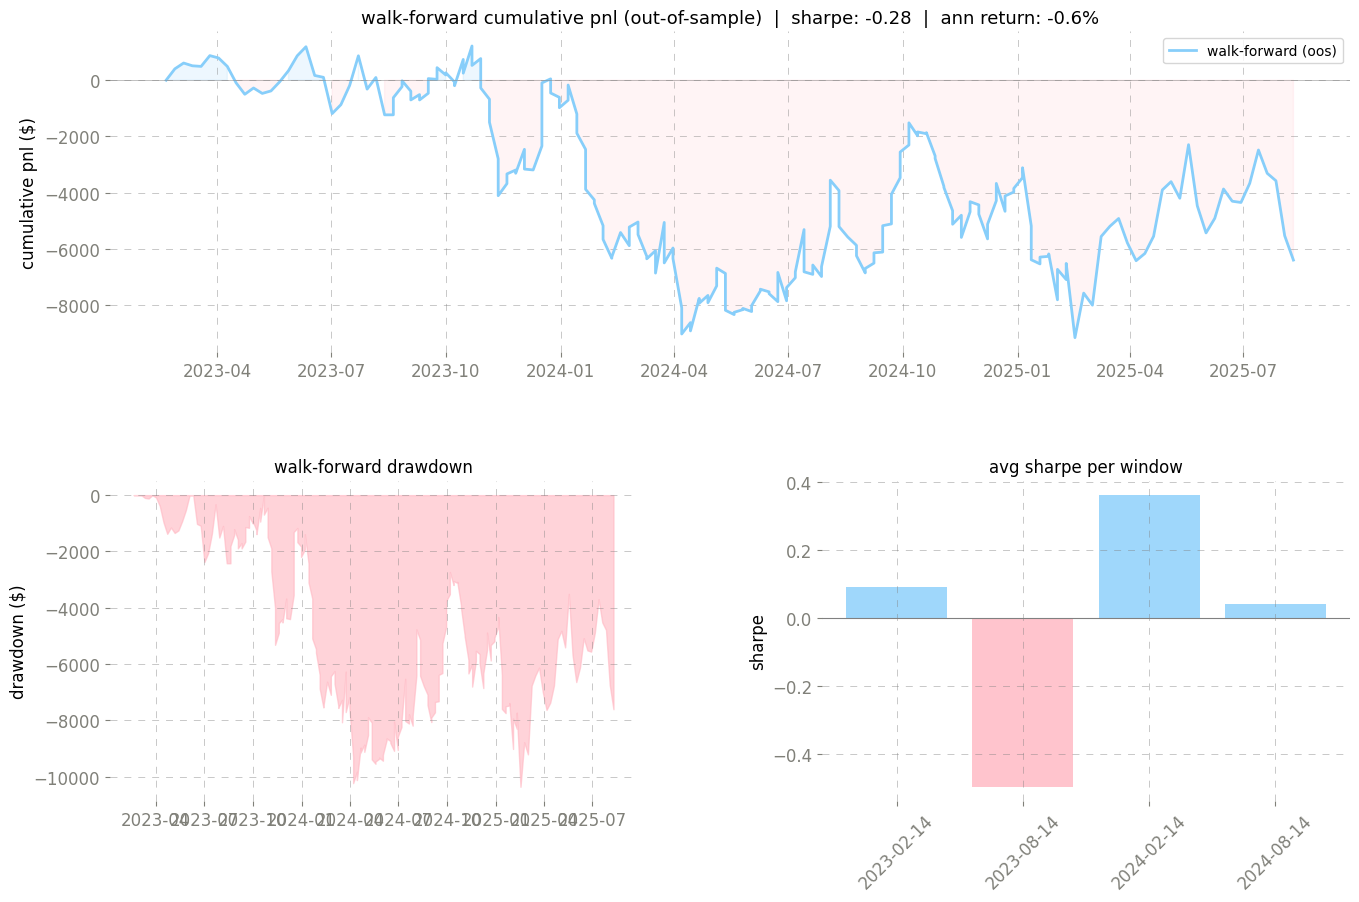

In [74]:
# visualisation
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size']   = 12

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# walk-forward cumulative pnl
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(port_cum.index, port_cum, linewidth=2, color='#87CEFA',
         label='walk-forward (oos)')
ax1.axhline(0, color='gray', linewidth=0.7, alpha=0.5)
ax1.fill_between(port_cum.index, port_cum, 0,
                 where=(port_cum >= 0), alpha=0.15, color='#87CEFA')
ax1.fill_between(port_cum.index, port_cum, 0,
                 where=(port_cum < 0),  alpha=0.15, color='#FFB6C1')
ax1.set_title(f'walk-forward cumulative pnl (out-of-sample)  |  '
              f'sharpe: {sharpe_wf:.2f}  |  ann return: {ann_ret*100:.1f}%', fontsize=13)
ax1.set_ylabel('cumulative pnl ($)')
ax1.legend(fontsize=10)
for s in ax1.spines.values(): s.set_visible(False)
ax1.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax1.tick_params(colors='#808079')

# drawdown
ax2 = fig.add_subplot(gs[1, 0])
dd = port_cum - port_cum.cummax()
ax2.fill_between(dd.index, dd, 0, color='#FFB6C1', alpha=0.6)
ax2.set_title('walk-forward drawdown', fontsize=12)
ax2.set_ylabel('drawdown ($)')
for s in ax2.spines.values(): s.set_visible(False)
ax2.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax2.tick_params(colors='#808079')

# per-window sharpe
ax3 = fig.add_subplot(gs[1, 1])
wf_per_window = (pd.DataFrame(all_window_results)
                 .groupby('window')['sharpe'].mean())
colors_bar = ['#87CEFA' if v >= 0 else '#FFB6C1' for v in wf_per_window]
ax3.bar(wf_per_window.index, wf_per_window.values, color=colors_bar, alpha=0.8)
ax3.axhline(0, color='gray', linewidth=0.8)
ax3.set_title('avg sharpe per window', fontsize=12)
ax3.set_ylabel('sharpe')
ax3.tick_params(axis='x', rotation=45)
for s in ax3.spines.values(): s.set_visible(False)
ax3.grid(True, color='gray', linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)
ax3.tick_params(colors='#808079')

plt.savefig("../results/pairs_walkforward.png", dpi=300, bbox_inches='tight')
plt.show()